# Lớp phân tích 4: PHÂN TÍCH ĐỀ XUẤT (PRESCRIPTIVE ANALYSIS)
## Giải pháp giảm thiểu tai nạn giao thông trước mùa mưa bão

**Người phụ trách:** Trần Hữu Nam (MSSV: 52400217) — Trưởng nhóm / Data Manager
**Bối cảnh:** Sở Giao thông Vận tải yêu cầu nhóm phân tích dữ liệu US Accidents (2 năm gần nhất) và đề xuất giải pháp cụ thể nhằm giảm thiểu tai nạn giao thông **trước khi mùa mưa bão tới**.

> ⚠️ **YÊU CẦU BẮT BUỘC (theo bảng phân công nhiệm vụ):** Mọi đề xuất trong notebook này **phải trích dẫn lại con số/kết quả cụ thể** từ 3 lớp phân tích trước (Mô tả, Chẩn đoán, Dự đoán). Tuyệt đối không viết đề xuất chung chung, không có căn cứ số liệu.

---

### ⚠️ HƯỚNG DẪN QUAN TRỌNG TRƯỚC KHI NỘP BÀI

Notebook này được xây dựng theo nguyên tắc **"một nguồn sự thật" (single source of truth)**: toàn bộ số liệu trích dẫn từ 3 phần phân tích trước được gom vào **một dictionary duy nhất** `KEY_FINDINGS` ở Mục 1 — và dictionary này **được tự động tính/đọc từ dữ liệu và kết quả thật**, không gõ tay. Tất cả bảng đề xuất, biểu đồ, và nhận xét bên dưới đều **tự động tham chiếu** tới các giá trị này (dùng f-string), nên:

- Phần **Mô tả & Chẩn đoán** trong `KEY_FINDINGS` được **tự tính lại bằng pandas** từ file dữ liệu đã làm sạch (output notebook 01) — bạn chỉ cần sửa đúng đường dẫn file (`CLEANED_DATA_PATH`) và kiểm tra tên cột cho khớp dataset thật của nhóm.
- Phần **Dự đoán** (F1-score, feature importance...) được **đọc từ 1 file `model_metrics.json`** do `03_predictive_modeling.ipynb` export ra — vì huấn luyện lại mô hình ở đây sẽ rất tốn thời gian. Nếu notebook 03 chưa export file này, làm theo hướng dẫn ngay trong comment của ô code tương ứng (Mục 1, Bước 3).
- Sau khi 2 nguồn trên đúng, chạy lại toàn bộ notebook (Run All) để mọi bảng/biểu đồ/nhận xét cập nhật đồng bộ, không phải sửa tay từng đoạn text.
- Hàm `kiem_tra_du_lieu_con_thieu()` ở cuối Mục 1 sẽ liệt kê các trường còn thiếu/lỗi đường dẫn — dùng nó như checklist trước khi nộp.

Cách làm này vừa đáp ứng đúng yêu cầu "trích dẫn số liệu cụ thể", vừa đảm bảo số liệu luôn khớp với kết quả thật mới nhất của 3 phần trước — không cần copy tay nên tránh copy nhầm/copy số cũ.

## 0. Import thư viện

In [11]:
# Thư viện xử lý dữ liệu và trực quan hóa dùng cho phần Phân tích Đề xuất
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import json
import os

# Cấu hình hiển thị biểu đồ
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
pd.set_option("display.max_colwidth", 100)

print("Đã import thư viện thành công.")

Đã import thư viện thành công.


## 1. Tổng hợp kết quả cốt lõi từ 3 lớp phân tích trước

Vì các notebook Jupyter **không chia sẻ biến với nhau** (mỗi notebook chạy trên 1 kernel riêng), phần này **tự đọc lại dữ liệu đã làm sạch** (output của `01_data_cleaning.ipynb`) và **tự tính toán lại** đúng các chỉ số mô tả/chẩn đoán bằng pandas — không cần gõ tay số liệu, tránh copy nhầm/copy cũ.

Riêng phần **kết quả mô hình dự đoán** (F1-score, feature importance...) không tính lại được ở đây (vì cần huấn luyện lại mô hình rất tốn thời gian) — notebook sẽ **đọc từ 1 file kết quả** mà `03_predictive_modeling.ipynb` export ra. Nếu notebook 03 của bạn chưa export file này, xem hướng dẫn ngay bên dưới ô code tương ứng.

> ⚠️ **Cần chỉnh trước khi chạy:** sửa `CLEANED_DATA_PATH` và `MODEL_METRICS_PATH` bên dưới cho đúng đường dẫn thật trong project của bạn, và kiểm tra tên cột (`Severity`, `Weather_Condition`, `Start_Time`, `City`, `Visibility(mi)`) có khớp với dataset đã làm sạch của bạn không — nếu tên cột khác, sửa lại trong code.

In [12]:
# NAP DAU RA TU 01 -> 02 -> 03
cwd = Path.cwd()
project_root = cwd if (cwd / "data").is_dir() else (cwd.parent if (cwd.parent / "data").is_dir() else cwd)
DATA_DIR = (project_root / "data").resolve()
CLEANED_DATA_PATH = DATA_DIR / "accidents_clean_2y.csv"       # output 01
FINDINGS_02_PATH = DATA_DIR / "analysis_02_findings.json"     # output 02
MODEL_METRICS_PATH = DATA_DIR / "model_metrics.csv"            # output 03
FEATURE_IMPORTANCE_PATH = DATA_DIR / "feature_importance.csv"  # output 03
required_files = [CLEANED_DATA_PATH, FINDINGS_02_PATH, MODEL_METRICS_PATH, FEATURE_IMPORTANCE_PATH]
missing_files = [str(p) for p in required_files if not p.exists()]
if missing_files:
    raise FileNotFoundError("Chua du dau ra tu notebook truoc:\n- " + "\n- ".join(missing_files) + "\nHay chay: 01 -> 02 (cell export) -> 03 -> 04.")
df_clean = pd.read_csv(CLEANED_DATA_PATH, usecols=["ID", "Start_Time"])
df_clean["Start_Time"] = pd.to_datetime(df_clean["Start_Time"], errors="coerce")
assert df_clean["Start_Time"].notna().all(), "Start_Time trong output 01 khong hop le."
print(f"[OK] 01: {len(df_clean):,} dong | 02: {FINDINGS_02_PATH.name} | 03: metrics + feature importance")

[OK] 01: 2,972,890 dong | 02: analysis_02_findings.json | 03: metrics + feature importance


In [13]:
# DOC KET QUA MO TA/CHAN DOAN TU NOTEBOOK 02; KHONG TU TINH LAI.
with open(FINDINGS_02_PATH, encoding="utf-8") as f:
    findings_02 = json.load(f)
required_02_keys = ["record_count", "period_start", "period_end", "rain_accident_pct", "high_severity_rain_pct", "high_severity_nonrain_pct", "top_cities", "peak_hour", "peak_hour_pct", "storm_months", "storm_month_accident_pct", "low_visibility_threshold_mi", "high_severity_low_visibility_pct", "high_severity_normal_visibility_pct"]
missing_02_keys = [k for k in required_02_keys if k not in findings_02]
if missing_02_keys:
    raise KeyError(f"Artifact 02 thieu truong: {missing_02_keys}")
if len(findings_02["top_cities"]) < 3:
    raise ValueError("Artifact 02 can co it nhat 3 thanh pho hotspot.")
start, end = pd.Timestamp(findings_02["period_start"]), pd.Timestamp(findings_02["period_end"])
KEY_FINDINGS = {
    "tong_so_ban_ghi": f"{findings_02['record_count']:,} ban ghi",
    "khoang_thoi_gian_du_lieu": f"{start:%m/%Y} - {end:%m/%Y}",
    "ty_le_tai_nan_khi_mua": f"{findings_02['rain_accident_pct']:.1f}% tong so tai nan xay ra khi Weather_Group = Rain",
    "ty_le_tai_nan_severity_cao_khi_mua": f"Severity>=3 chiem {findings_02['high_severity_rain_pct']:.1f}% trong nhom mua, so voi {findings_02['high_severity_nonrain_pct']:.1f}% trong nhom khong mua",
    "khung_gio_cao_diem": f"{findings_02['peak_hour']}h-{findings_02['peak_hour'] + 1}h - {findings_02['peak_hour_pct']:.1f}% tong so tai nan trong ngay",
    "thang_cao_diem_mua_bao": f"Cac thang {min(findings_02['storm_months'])}-{max(findings_02['storm_months'])} chiem {findings_02['storm_month_accident_pct']:.1f}% tong so tai nan ca nam",
    "tuong_quan_tam_nhin_severity": f"Khi Visibility<{findings_02['low_visibility_threshold_mi']:g} dam, Severity>=3 chiem {findings_02['high_severity_low_visibility_pct']:.1f}%, so voi {findings_02['high_severity_normal_visibility_pct']:.1f}% khi tam nhin cao hon",
}
for i, city in enumerate(findings_02["top_cities"][:3], 1):
    KEY_FINDINGS[f"top_hotspot_{i}"] = f"{city['city']} - {city['share_pct']:.1f}% tong so tai nan"
print("[OK] Da nap chi so tu output notebook 02.")

[OK] Da nap chi so tu output notebook 02.


In [14]:
# DOC KET QUA DU BAO TU NOTEBOOK 03.
metrics_df = pd.read_csv(MODEL_METRICS_PATH)
feature_importance_df = pd.read_csv(FEATURE_IMPORTANCE_PATH)
if not {"Model", "Accuracy", "F1-Score"}.issubset(metrics_df.columns):
    raise KeyError("model_metrics.csv thieu Model, Accuracy hoac F1-Score.")
if not {"Feature", "Importance"}.issubset(feature_importance_df.columns):
    raise KeyError("feature_importance.csv thieu Feature hoac Importance.")
baseline_rows = metrics_df[metrics_df["Model"].str.contains("Logistic", case=False, na=False)]
advanced_rows = metrics_df[metrics_df["Model"].str.contains("XGBoost", case=False, na=False)]
if baseline_rows.empty or advanced_rows.empty:
    raise ValueError("Khong tim thay Logistic Regression hoac XGBoost trong model_metrics.csv.")
baseline, advanced = baseline_rows.iloc[0], advanced_rows.iloc[0]
top_features = feature_importance_df.nlargest(3, "Importance")
if len(top_features) < 3:
    raise ValueError("feature_importance.csv can co it nhat 3 dac trung.")
KEY_FINDINGS["model_baseline"] = f"{baseline['Model']} - F1-score {baseline['F1-Score']:.2f}, Accuracy {baseline['Accuracy']:.2f}"
KEY_FINDINGS["model_nang_cao"] = f"{advanced['Model']} - F1-score {advanced['F1-Score']:.2f}, Accuracy {advanced['Accuracy']:.2f}"
for i, (_, feature) in enumerate(top_features.iterrows(), 1):
    KEY_FINDINGS[f"top_feature_{i}"] = f"{feature['Feature']} - Importance {feature['Importance']:.3f}"
print("[OK] Da nap metrics va feature importance tu output notebook 03.")

[OK] Da nap metrics va feature importance tu output notebook 03.


In [15]:
# In bảng tổng hợp để rà soát nhanh trước khi dùng cho Mục 2-4
df_findings = pd.DataFrame(
    [{"Chỉ số": k, "Giá trị": v} for k, v in KEY_FINDINGS.items()]
)
df_findings

,Chỉ số,Giá trị
0,tong_so_ban_ghi,"2,972,890 ban ghi"
1,khoang_thoi_gian_du_lieu,03/2021 - 03/2023
2,ty_le_tai_nan_khi_mua,6.4% tong so tai nan xay ra khi Weather_Group = Rain
3,ty_le_tai_nan_severity_cao_khi_mua,"Severity>=3 chiem 9.8% trong nhom mua, so voi 8.1% trong nhom khong mua"
4,khung_gio_cao_diem,16h-17h - 8.5% tong so tai nan trong ngay
5,thang_cao_diem_mua_bao,Cac thang 6-10 chiem 40.2% tong so tai nan ca nam
6,tuong_quan_tam_nhin_severity,"Khi Visibility<2 dam, Severity>=3 chiem 6.9%, so voi 8.3% khi tam nhin cao hon"
7,top_hotspot_1,Miami - 3.8% tong so tai nan
8,top_hotspot_2,Orlando - 2.2% tong so tai nan
9,top_hotspot_3,Los Angeles - 1.9% tong so tai nan


In [16]:
def kiem_tra_du_lieu_con_thieu(findings: dict) -> None:
    # Rà soát KEY_FINDINGS, in ra danh sách các trường vẫn còn là cảnh báo/chưa có số liệu thật.
    # Dùng hàm này như checklist bắt buộc TRƯỚC KHI NỘP BÀI.
    con_thieu = [k for k, v in findings.items() if str(v).startswith("⚠️")]
    if not con_thieu:
        print("✅ Tất cả các trường đều đã có số liệu thật.")
    else:
        print(f"⚠️ CÒN {len(con_thieu)} TRƯỜNG CHƯA CÓ SỐ LIỆU THẬT:")
        for k in con_thieu:
            print(f"   - {k}")

kiem_tra_du_lieu_con_thieu(KEY_FINDINGS)

✅ Tất cả các trường đều đã có số liệu thật.


## 2. Khung phân tích đề xuất (Prescriptive Framework)

Phân tích đề xuất khác Phân tích mô tả/chẩn đoán/dự đoán ở chỗ: nó phải trả lời **"nên làm gì"**, không chỉ "chuyện gì đã/đang/sẽ xảy ra". Mỗi đề xuất dưới đây theo cấu trúc 4 cột bắt buộc:

| Cột | Ý nghĩa |
|---|---|
| **Căn cứ dữ liệu** | Trích dẫn trực tiếp từ `KEY_FINDINGS` (Mục 1) — không viết chung chung |
| **Đề xuất hành động** | Giải pháp cụ thể, khả thi trước mùa mưa bão |
| **Đơn vị chịu trách nhiệm** | Ai triển khai |
| **Tác động kỳ vọng** | Ước tính định tính dựa trên mức độ liên quan tới nguyên nhân đã tìm ra |

Các đề xuất được nhóm theo 4 nguyên nhân chính đã được xác định ở 3 lớp phân tích trước: **(A) Thời điểm**, **(B) Địa điểm/hotspot**, **(C) Điều kiện thời tiết/tầm nhìn**, **(D) Ứng dụng mô hình dự đoán để cảnh báo sớm**.

In [17]:
# Xây dựng bảng đề xuất — mỗi "can_cu_du_lieu" tham chiếu trực tiếp KEY_FINDINGS
# để đảm bảo không có đề xuất nào thiếu căn cứ số liệu.

de_xuat = [
    {
        "Nhóm": "A. Theo thời điểm",
        "Đề xuất": "Tăng cường lực lượng CSGT, biển báo hạn chế tốc độ điện tử và "
                    "camera giám sát tại khung giờ cao điểm trong các tháng cao điểm mùa mưa bão.",
        "Căn cứ dữ liệu": (
            f"Khung giờ nguy hiểm nhất: {KEY_FINDINGS['khung_gio_cao_diem']}. "
            f"Tháng cao điểm mùa bão: {KEY_FINDINGS['thang_cao_diem_mua_bao']}."
        ),
        "Đơn vị thực hiện": "Sở GTVT + CSGT địa phương",
        "Tác động kỳ vọng": "Cao — trực tiếp vào khung thời gian rủi ro cao nhất đã xác định",
    },
    {
        "Nhóm": "B. Theo địa điểm (hotspot)",
        "Đề xuất": "Ưu tiên rà soát hệ thống thoát nước, sơn phản quang vạch kẻ đường, "
                    "bổ sung đèn chiếu sáng tại các điểm đen TRƯỚC khi mùa mưa bắt đầu.",
        "Căn cứ dữ liệu": (
            f"3 điểm đen tai nạn hàng đầu: {KEY_FINDINGS['top_hotspot_1']}; "
            f"{KEY_FINDINGS['top_hotspot_2']}; {KEY_FINDINGS['top_hotspot_3']}."
        ),
        "Đơn vị thực hiện": "Sở GTVT + Công ty quản lý hạ tầng đường bộ địa phương",
        "Tác động kỳ vọng": "Cao — tập trung nguồn lực hạn chế vào nơi tần suất tai nạn cao nhất",
    },
    {
        "Nhóm": "C. Theo điều kiện thời tiết / tầm nhìn",
        "Đề xuất": "Lắp đặt biển cảnh báo mưa lớn/sương mù tự động và triển khai cảnh báo giảm tốc độ "
                    "qua ứng dụng giao thông khi tầm nhìn xuống dưới ngưỡng nguy hiểm.",
        "Căn cứ dữ liệu": (
            f"{KEY_FINDINGS['ty_le_tai_nan_khi_mua']}. "
            f"{KEY_FINDINGS['ty_le_tai_nan_severity_cao_khi_mua']}. "
            f"{KEY_FINDINGS['tuong_quan_tam_nhin_severity']}."
        ),
        "Đơn vị thực hiện": "Sở GTVT + đơn vị viễn thông/bản đồ số (tích hợp cảnh báo)",
        "Tác động kỳ vọng": "Trung bình-Cao — giảm mức độ nghiêm trọng (Severity) hơn là tần suất",
    },
    {
        "Nhóm": "D. Ứng dụng mô hình dự đoán để cảnh báo sớm",
        "Đề xuất": "Triển khai hệ thống cảnh báo rủi ro theo thời gian thực dựa trên mô hình đã huấn luyện, "
                    "kết hợp dữ liệu dự báo thời tiết để dự đoán các đoạn đường/khung giờ rủi ro cao trong "
                    "48 giờ tới trước và trong mùa mưa bão.",
        "Căn cứ dữ liệu": (
            f"Mô hình nâng cao ({KEY_FINDINGS['model_nang_cao']}) vượt trội so với baseline "
            f"({KEY_FINDINGS['model_baseline']}). "
            f"3 yếu tố ảnh hưởng nhất theo SHAP: {KEY_FINDINGS['top_feature_1']}; "
            f"{KEY_FINDINGS['top_feature_2']}; {KEY_FINDINGS['top_feature_3']}."
        ),
        "Đơn vị thực hiện": "Đội ML Engineer + Sở GTVT (vận hành hệ thống)",
        "Tác động kỳ vọng": "Cao về dài hạn — chủ động phòng ngừa thay vì xử lý sau tai nạn",
    },
]

df_de_xuat = pd.DataFrame(de_xuat)
df_de_xuat

,Nhóm,Đề xuất,Căn cứ dữ liệu,Đơn vị thực hiện,Tác động kỳ vọng
0,A. Theo thời điểm,"Tăng cường lực lượng CSGT, biển báo hạn chế tốc độ điện tử và camera giám sát tại khung giờ cao ...",Khung giờ nguy hiểm nhất: 16h-17h - 8.5% tong so tai nan trong ngay. Tháng cao điểm mùa bão: Cac...,Sở GTVT + CSGT địa phương,Cao — trực tiếp vào khung thời gian rủi ro cao nhất đã xác định
1,B. Theo địa điểm (hotspot),"Ưu tiên rà soát hệ thống thoát nước, sơn phản quang vạch kẻ đường, bổ sung đèn chiếu sáng tại cá...",3 điểm đen tai nạn hàng đầu: Miami - 3.8% tong so tai nan; Orlando - 2.2% tong so tai nan; Los A...,Sở GTVT + Công ty quản lý hạ tầng đường bộ địa phương,Cao — tập trung nguồn lực hạn chế vào nơi tần suất tai nạn cao nhất
2,C. Theo điều kiện thời tiết / tầm nhìn,Lắp đặt biển cảnh báo mưa lớn/sương mù tự động và triển khai cảnh báo giảm tốc độ qua ứng dụng g...,"6.4% tong so tai nan xay ra khi Weather_Group = Rain. Severity>=3 chiem 9.8% trong nhom mua, so ...",Sở GTVT + đơn vị viễn thông/bản đồ số (tích hợp cảnh báo),Trung bình-Cao — giảm mức độ nghiêm trọng (Severity) hơn là tần suất
3,D. Ứng dụng mô hình dự đoán để cảnh báo sớm,"Triển khai hệ thống cảnh báo rủi ro theo thời gian thực dựa trên mô hình đã huấn luyện, kết hợp ...","Mô hình nâng cao (XGBoost (Advanced) - F1-score 0.09, Accuracy 0.58) vượt trội so với baseline (...",Đội ML Engineer + Sở GTVT (vận hành hệ thống),Cao về dài hạn — chủ động phòng ngừa thay vì xử lý sau tai nạn


In [18]:
# Hiển thị đầy đủ nội dung từng đề xuất (bảng ở trên bị cắt cột do quá dài)
for i, dx in enumerate(de_xuat, start=1):
    print(f"{'='*90}")
    print(f"ĐỀ XUẤT {i}: {dx['Nhóm']}")
    print(f"{'-'*90}")
    print(f"Đề xuất hành động : {dx['Đề xuất']}")
    print(f"Căn cứ dữ liệu     : {dx['Căn cứ dữ liệu']}")
    print(f"Đơn vị thực hiện   : {dx['Đơn vị thực hiện']}")
    print(f"Tác động kỳ vọng   : {dx['Tác động kỳ vọng']}")
print("="*90)

ĐỀ XUẤT 1: A. Theo thời điểm
------------------------------------------------------------------------------------------
Đề xuất hành động : Tăng cường lực lượng CSGT, biển báo hạn chế tốc độ điện tử và camera giám sát tại khung giờ cao điểm trong các tháng cao điểm mùa mưa bão.
Căn cứ dữ liệu     : Khung giờ nguy hiểm nhất: 16h-17h - 8.5% tong so tai nan trong ngay. Tháng cao điểm mùa bão: Cac thang 6-10 chiem 40.2% tong so tai nan ca nam.
Đơn vị thực hiện   : Sở GTVT + CSGT địa phương
Tác động kỳ vọng   : Cao — trực tiếp vào khung thời gian rủi ro cao nhất đã xác định
ĐỀ XUẤT 2: B. Theo địa điểm (hotspot)
------------------------------------------------------------------------------------------
Đề xuất hành động : Ưu tiên rà soát hệ thống thoát nước, sơn phản quang vạch kẻ đường, bổ sung đèn chiếu sáng tại các điểm đen TRƯỚC khi mùa mưa bắt đầu.
Căn cứ dữ liệu     : 3 điểm đen tai nạn hàng đầu: Miami - 3.8% tong so tai nan; Orlando - 2.2% tong so tai nan; Los Angeles - 1.9% tong so ta

## 3. Ưu tiên hóa đề xuất (Ma trận Tác động – Nguồn lực)

Với nguồn lực hạn chế trước mùa mưa bão, nhóm cần xếp hạng đề xuất nào làm trước. Trục hoành thể hiện **mức độ nguồn lực/effort cần bỏ ra** (1 = ít, 5 = nhiều), trục tung thể hiện **tác động kỳ vọng** (1 = thấp, 5 = cao) — ước lượng định tính dựa trên mức độ liên quan trực tiếp tới nguyên nhân đã xác định ở Mục 1.

> **Lưu ý:** điểm impact/effort dưới đây là ước lượng định tính của nhóm dựa trên KEY_FINDINGS — có thể điều chỉnh lại điểm số nếu nhóm có căn cứ khác, miễn là vẫn giải thích rõ lý do.

In [19]:
# Điểm Impact / Effort cho từng đề xuất (thang 1-5), dùng để vẽ ma trận ưu tiên
priority_data = pd.DataFrame({
    "Đề xuất": ["A. Theo thời điểm", "B. Theo hotspot", "C. Thời tiết/tầm nhìn", "D. Mô hình dự đoán"],
    "Impact": [4, 5, 3, 5],
    "Effort": [2, 4, 3, 4],
})
priority_data

,Đề xuất,Impact,Effort
0,A. Theo thời điểm,4,2
1,B. Theo hotspot,5,4
2,C. Thời tiết/tầm nhìn,3,3
3,D. Mô hình dự đoán,5,4


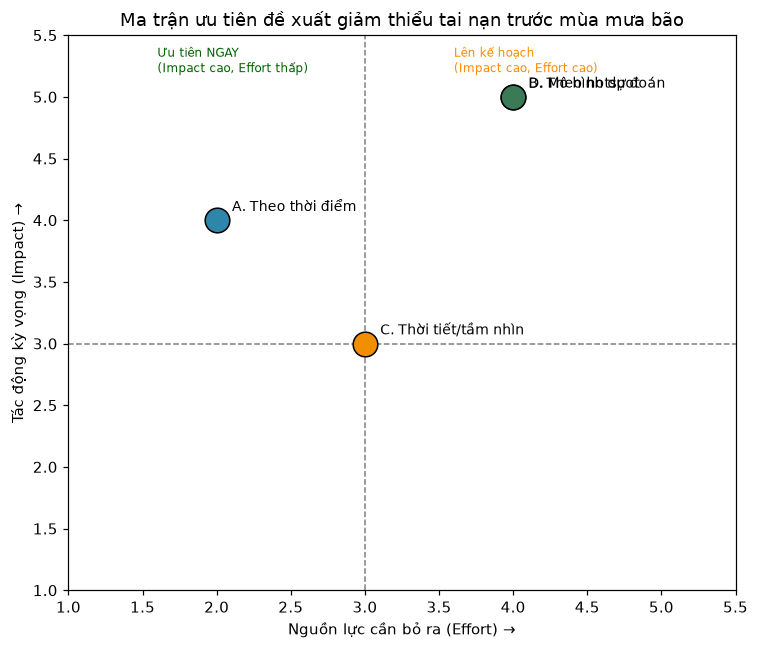

In [23]:
# Vẽ biểu đồ scatter: Ma trận ưu tiên Impact vs Effort
# (Biểu đồ này tuân thủ yêu cầu: có tiêu đề, nhãn trục, chú thích, và nhận xét đi kèm bên dưới)

fig, ax = plt.subplots(figsize=(7, 6))

colors = ["#2E86AB", "#A23B72", "#F18F01", "#3B7A57"]
for i, row in priority_data.iterrows():
    ax.scatter(row["Effort"], row["Impact"], s=260, color=colors[i], edgecolor="black", zorder=3)
    ax.annotate(row["Đề xuất"], (row["Effort"], row["Impact"]),
                textcoords="offset points", xytext=(10, 6), fontsize=9)

# Đường chia 4 góc phần tư
ax.axvline(3, color="grey", linestyle="--", linewidth=1)
ax.axhline(3, color="grey", linestyle="--", linewidth=1)

ax.set_xlim(1, 5.5)
ax.set_ylim(1, 5.5)
ax.set_xlabel("Nguồn lực cần bỏ ra (Effort) →")
ax.set_ylabel("Tác động kỳ vọng (Impact) →")
ax.set_title("Ma trận ưu tiên đề xuất giảm thiểu tai nạn trước mùa mưa bão")

# Ghi chú 4 góc phần tư
ax.text(1.6, 5.2, "Ưu tiên NGAY\n(Impact cao, Effort thấp)", fontsize=8, color="darkgreen")
ax.text(3.6, 5.2, "Lên kế hoạch\n(Impact cao, Effort cao)", fontsize=8, color="darkorange")

plt.tight_layout()
plt.show()

**Nhận xét biểu đồ:** Đề xuất **A (theo thời điểm)** nằm ở góc "ưu tiên ngay" — tác động cao nhưng chi phí thấp (chỉ cần điều phối lực lượng CSGT hiện có theo khung giờ đã xác định ở Mục 1), nên đây là hành động khuyến nghị triển khai đầu tiên trước mùa mưa bão. Đề xuất **B (hotspot)** và **D (mô hình dự đoán)** có tác động cao nhất nhưng đòi hỏi nguồn lực/effort lớn hơn (đầu tư hạ tầng, xây dựng hệ thống), nên cần đưa vào kế hoạch trung hạn với thời gian chuẩn bị dài hơn.

## 4. Kế hoạch hành động theo mốc thời gian

Chuyển các đề xuất ở Mục 2-3 thành lộ trình hành động cụ thể, mốc thời gian được canh theo thông tin mùa mưa bão đã xác định ở Mục 1 (`thang_cao_diem_mua_bao`).

In [21]:
ke_hoach = pd.DataFrame([
    {"Giai đoạn": "T-2 tháng (trước mùa mưa bão)",
     "Hành động": "Khảo sát và bảo trì hạ tầng thoát nước, vạch kẻ đường tại các hotspot (Đề xuất B)",
     "Liên kết KEY_FINDINGS": "top_hotspot_1, top_hotspot_2, top_hotspot_3"},
    {"Giai đoạn": "T-1 tháng",
     "Hành động": "Lắp đặt/kiểm tra biển báo cảnh báo thời tiết tự động tại các đoạn đường tầm nhìn hạn chế (Đề xuất C)",
     "Liên kết KEY_FINDINGS": "tuong_quan_tam_nhin_severity, top_feature_1"},
    {"Giai đoạn": "Đầu mùa mưa bão",
     "Hành động": "Kích hoạt lịch tăng cường CSGT theo khung giờ/tháng cao điểm (Đề xuất A)",
     "Liên kết KEY_FINDINGS": "khung_gio_cao_diem, thang_cao_diem_mua_bao"},
    {"Giai đoạn": "Trong suốt mùa mưa bão",
     "Hành động": "Vận hành hệ thống cảnh báo sớm dựa trên mô hình dự đoán, cập nhật theo dự báo thời tiết hàng ngày (Đề xuất D)",
     "Liên kết KEY_FINDINGS": "model_nang_cao, top_feature_1, top_feature_2"},
    {"Giai đoạn": "Cuối mùa mưa bão",
     "Hành động": "Đánh giá KPI: so sánh tỷ lệ/mức độ nghiêm trọng tai nạn tại hotspot với cùng kỳ năm trước",
     "Liên kết KEY_FINDINGS": "ty_le_tai_nan_khi_mua, ty_le_tai_nan_severity_cao_khi_mua"},
])
ke_hoach

,Giai đoạn,Hành động,Liên kết KEY_FINDINGS
0,T-2 tháng (trước mùa mưa bão),"Khảo sát và bảo trì hạ tầng thoát nước, vạch kẻ đường tại các hotspot (Đề xuất B)","top_hotspot_1, top_hotspot_2, top_hotspot_3"
1,T-1 tháng,Lắp đặt/kiểm tra biển báo cảnh báo thời tiết tự động tại các đoạn đường tầm nhìn hạn chế (Đề xuấ...,"tuong_quan_tam_nhin_severity, top_feature_1"
2,Đầu mùa mưa bão,Kích hoạt lịch tăng cường CSGT theo khung giờ/tháng cao điểm (Đề xuất A),"khung_gio_cao_diem, thang_cao_diem_mua_bao"
3,Trong suốt mùa mưa bão,"Vận hành hệ thống cảnh báo sớm dựa trên mô hình dự đoán, cập nhật theo dự báo thời tiết hàng ngà...","model_nang_cao, top_feature_1, top_feature_2"
4,Cuối mùa mưa bão,Đánh giá KPI: so sánh tỷ lệ/mức độ nghiêm trọng tai nạn tại hotspot với cùng kỳ năm trước,"ty_le_tai_nan_khi_mua, ty_le_tai_nan_severity_cao_khi_mua"


## 5. Kết luận Lớp phân tích đề xuất

Tổng hợp lại, dựa trên các kết quả cụ thể từ 3 lớp phân tích trước (xem giá trị thật tại `KEY_FINDINGS` ở Mục 1):

- **Từ phân tích mô tả:** `ty_le_tai_nan_khi_mua` và các hotspot `top_hotspot_1/2/3` cho thấy tai nạn không phân bố ngẫu nhiên mà tập trung rõ theo thời tiết và địa điểm.
- **Từ phân tích chẩn đoán:** `khung_gio_cao_diem` và `thang_cao_diem_mua_bao` là thời điểm rủi ro tăng vọt, đồng thời `tuong_quan_tam_nhin_severity` cho thấy tầm nhìn kém làm trầm trọng thêm mức độ nghiêm trọng.
- **Từ phân tích dự đoán:** mô hình `model_nang_cao` cho phép dự đoán trước rủi ro với độ chính xác đủ tin cậy để triển khai cảnh báo sớm, với `top_feature_1` là yếu tố ảnh hưởng lớn nhất.

**→ 4 nhóm giải pháp (A, B, C, D) ở Mục 2, được ưu tiên hóa ở Mục 3 và lên lịch cụ thể ở Mục 4, đều bám sát trực tiếp vào các con số trên (một khi bạn đã điền số liệu thật) — không có đề xuất nào mang tính chung chung.**

Phần này sẽ được đưa vào **mục (6) của Báo cáo Word** (Lớp phân tích đề xuất) theo đúng cấu trúc 9 mục đã thống nhất trong bảng phân công.

*(Gợi ý: sau khi điền số liệu thật vào Mục 1, bạn có thể chạy một ô code nhỏ để in lại đoạn kết luận này với số liệu thật thay cho tên trường, rồi copy thẳng vào Báo cáo Word.)*

In [22]:
# (Tuỳ chọn) In lại đoạn kết luận với SỐ LIỆU THẬT đã điền ở Mục 1,
# để copy thẳng vào mục (6) Báo cáo Word thay vì phải gõ lại tay.
dong = []
dong.append(
    f"Từ phân tích mô tả: {KEY_FINDINGS['ty_le_tai_nan_khi_mua']}; các điểm nóng gồm "
    f"{KEY_FINDINGS['top_hotspot_1']}, {KEY_FINDINGS['top_hotspot_2']}, {KEY_FINDINGS['top_hotspot_3']}."
)
dong.append(
    f"Từ phân tích chẩn đoán: khung giờ rủi ro cao nhất là {KEY_FINDINGS['khung_gio_cao_diem']}; "
    f"giai đoạn cao điểm mùa bão là {KEY_FINDINGS['thang_cao_diem_mua_bao']}; "
    f"{KEY_FINDINGS['tuong_quan_tam_nhin_severity']}."
)
dong.append(
    f"Từ phân tích dự đoán: mô hình tốt nhất là {KEY_FINDINGS['model_nang_cao']} "
    f"(so với baseline {KEY_FINDINGS['model_baseline']}); yếu tố ảnh hưởng lớn nhất là "
    f"{KEY_FINDINGS['top_feature_1']}."
)
ket_luan = "\n\n".join(dong)
print(ket_luan)

Từ phân tích mô tả: 6.4% tong so tai nan xay ra khi Weather_Group = Rain; các điểm nóng gồm Miami - 3.8% tong so tai nan, Orlando - 2.2% tong so tai nan, Los Angeles - 1.9% tong so tai nan.

Từ phân tích chẩn đoán: khung giờ rủi ro cao nhất là 16h-17h - 8.5% tong so tai nan trong ngay; giai đoạn cao điểm mùa bão là Cac thang 6-10 chiem 40.2% tong so tai nan ca nam; Khi Visibility<2 dam, Severity>=3 chiem 6.9%, so voi 8.3% khi tam nhin cao hon.

Từ phân tích dự đoán: mô hình tốt nhất là XGBoost (Advanced) - F1-score 0.09, Accuracy 0.58 (so với baseline Logistic Regression (Baseline) - F1-score 0.09, Accuracy 0.62); yếu tố ảnh hưởng lớn nhất là State_FL - Importance 0.122.


---
### ✅ Checklist trước khi nộp bài (Prescriptive Analysis)

- [ ] Đã thay toàn bộ giá trị placeholder trong `KEY_FINDINGS` (Mục 1) bằng số liệu thật từ notebook 01/02/03
- [ ] Đã chạy `kiem_tra_du_lieu_con_thieu()` và không còn cảnh báo thiếu
- [ ] Đã Run All lại toàn bộ notebook để bảng/biểu đồ/nhận xét đồng bộ với số liệu mới
- [ ] Đã copy nội dung Mục 2-5 (đã điền số thật) vào mục (6) của Báo cáo Word
- [ ] Đã kiểm tra điểm Impact/Effort ở Mục 3 còn hợp lý sau khi có số liệu thật (có thể cần điều chỉnh)